<h3 style="color: #e0e0ff; font-style: italic;">🔍 EDA, Data Cleaning and Feature Engineering</h3>

---

**Note:** This M4FC (Multimodal, Multilingual, Multicultural, Multitask) dataset is built from professional fact-checking organizations, which makes it have high-quality, real-world data across many languages. It was specifically curated for "Verdict Prediction" (fake news detection).

**Loading libraries** 

In [1]:
import os
import json
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from collections import Counter

import sys
sys.path.insert(0, os.path.abspath("../../src"))
from data_pipeline import M4FCDataPipeline


**Loading M4FC Dataset** 

In [2]:
def load_m4fc_data(root_path):
    json_path = os.path.join(root_path, 'data', 'M4FC.json')
    img_base_dir = os.path.join(root_path, 'data_wayback')
    
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"❌ Metadata missing at {json_path}. Check README setup.")
    
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)

    # Path Engineering
    df['full_image_path'] = img_base_dir + os.sep + df['image_path'].str.replace('/', os.sep, regex=False)
    df['full_image_path'] = df['full_image_path'].apply(os.path.normpath)
    
    df['image_exists'] = df['full_image_path'].apply(os.path.exists)
    
    # Summary Statistics
    total = len(df)
    found = df['image_exists'].sum()
    print(f"✅ Dataset Loaded: {total} claims.")
    print(f"🖼️ Images Found: {found}/{total} ({found/total*100:.3f}%)")
    print(f"❌ Missing: {total - found}")
    
    return df

M4FC_ROOT = os.path.join('../..', 'M4FC')
df = load_m4fc_data(M4FC_ROOT)

✅ Dataset Loaded: 4982 claims.
🖼️ Images Found: 4981/4982 (99.980%)
❌ Missing: 1


**Quick inspection**

In [3]:
columns = df.columns.tolist()
n_columns = len(columns)
print("\n🔍 Column Profile:")
print(f"   ├─ Total columns: {n_columns}")
print(f"   └─ Column names: {', '.join(columns)}")

n_languages = df['fc_language'].nunique()
languages = df['fc_language'].unique()
print(f"\n🌍 Language Detection Summary")
print(f"   ├─ Unique languages found: {n_languages}")
print(f"   └─ Languages: {', '.join(sorted(languages))}")

pd.set_option('display.max_columns', None)
display(df.head(3))


🔍 Column Profile:
   ├─ Total columns: 47
   └─ Column names: image_path, image_url, article_url, fc_org, fc_pub_date, fc_language, fc_country, verification_strategy, verification_tools, claim, multilingual_claim, claim_language, verdict, claimant, claimant_intent, claimed_date, claimed_location, claimed_people, claimed_things, claimed_event, provenance, source, date, location, motivation, people, things, event, task_claim_extraction, task_location_verification, true_caption, task_claimant_intent, task_fake_detection, task_image_contextualization, split, is_ai_generated, use_true_caption, negative_geolocations, coordinates, negative_coordinates, is_manipulated_fake, verdict_coarse, multilingual_true_caption, task_verdict_prediction, wayback_image_url, full_image_path, image_exists

🌍 Language Detection Summary
   ├─ Unique languages found: 15
   └─ Languages: arabic, chinese, danish, dutch, english, french, german, greek, japanese, kannada, portuguese, spanish, tamil, telugu, turkish


,image_path,image_url,article_url,fc_org,fc_pub_date,fc_language,fc_country,verification_strategy,verification_tools,claim,multilingual_claim,claim_language,verdict,claimant,claimant_intent,claimed_date,claimed_location,claimed_people,claimed_things,claimed_event,provenance,source,date,location,motivation,people,things,event,task_claim_extraction,task_location_verification,true_caption,task_claimant_intent,task_fake_detection,task_image_contextualization,split,is_ai_generated,use_true_caption,negative_geolocations,coordinates,negative_coordinates,is_manipulated_fake,verdict_coarse,multilingual_true_caption,task_verdict_prediction,wayback_image_url,full_image_path,image_exists
0,images/الأرانب-تلد-ولا-تبيض-وصور-هذا-البيض-لا-...,https://cdn4.fatabyyano.net/wp-content/uploads...,https://fatabyyano.net/الأرانب-تلد-ولا-تبيض-وص...,fatabyyano.net,2021-12-19 19:36:09,arabic,Jordan,reverse image search,google,Rabbits lay eggs,الأرانب تبيض,Arabic,false (out-of-context),Akram Rajeh Al-Rajhi,Entertainment,not enough information,not enough information,not enough information,Rabbit eggs,not enough information,yes,not enough information,not enough information,not enough information,Entertainment,not enough information,Bird eggs,not enough information,False,False,not enough information,True,True,True,train,False,False,not enough information,not enough information,not enough information,False,false,not enough information,True,https://web.archive.org/web/20220404045630/htt...,..\..\M4FC\data_wayback\images\الأرانب-تلد-ولا...,True
1,images/الشاب-الذي-يظهر-في-الصورة-من-مصر-وهو-ما...,https://cdn4.fatabyyano.net/wp-content/uploads...,https://fatabyyano.net/الشاب-الذي-يظهر-في-الصو...,fatabyyano.net,2021-03-07 16:57:55,arabic,Jordan,reverse image search,not enough information,The young man is from Syria and has committed ...,الشاب الذي يظهر في الصورة من سوريا وأنه انتحر,Arabic,false (out-of-context),Ghidaq Sarhan's Facebook page,not enough information,not enough information,"Damascus, Syria",Ali Mousa,not enough information,Suicide,yes,not enough information,not enough information,Egypt,not enough information,[mohamed el - menshawy],not enough information,not enough information,True,False,not enough information,False,True,True,train,False,False,not enough information,not enough information,not enough information,False,false,not enough information,True,https://web.archive.org/web/20251019124008/htt...,..\..\M4FC\data_wayback\images\الشاب-الذي-يظهر...,True
2,images/الصور-تعود-إلى-مبادرة-في-العراق-ليس-الأ...,https://cdn4.fatabyyano.net/wp-content/uploads...,https://fatabyyano.net/%D8%A7%D9%84%D8%B5%D9%8...,fatabyyano.net,2021-01-11 23:30:26,arabic,Jordan,keyword search,google,A new and beautiful initiative in Jordan.,مبادرة جديدة و جميلة في الأردن,Arabic,false (out-of-context),"Page ""كل شي حلو"" on Facebook",not enough information,not enough information,Jordan,not enough information,Coats,Distribution of coats in the streets as part o...,yes,"Ali Hakim, Director of the ""Shababna"" campaign",2020-12-26,"Karbala, Iraq",To help those in need during the cold winter a...,not enough information,"Coats, jackets",Warmth initiative in Iraq,True,False,Iraqi volunteers participate in the Warmth ini...,False,True,True,train,False,True,not enough information,not enough information,not enough information,False,false,يشارك المتطوعون العراقيون في مبادرة الدفء في ك...,True,https://web.archive.org/web/20250101163221/htt...,..\..\M4FC\data_wayback\images\الصور-تعود-إلى-...,True


**EDA**

In [4]:
os.makedirs('../reports/eda', exist_ok=True)

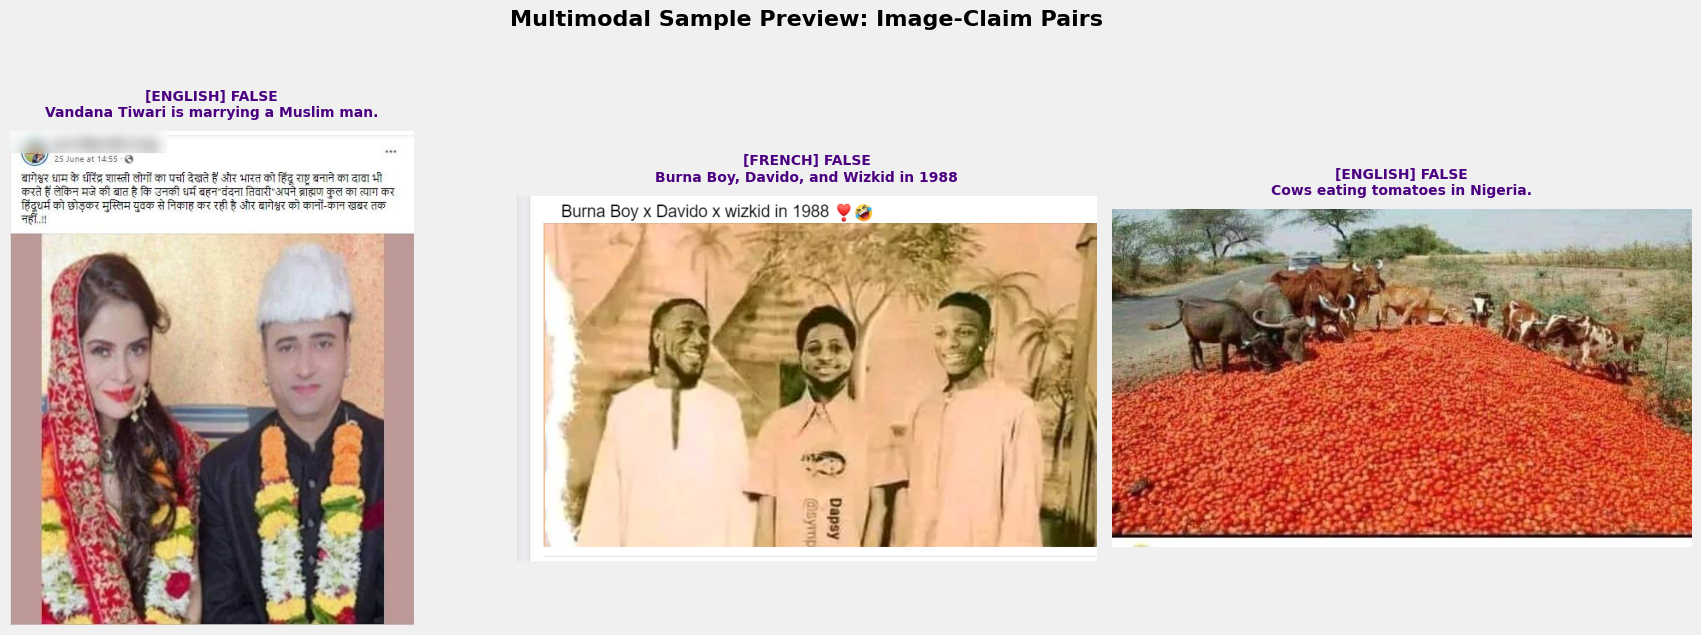

In [5]:
def preview_random_samples(df, n=3, seed=42):
    available_df = df[df['image_exists'] == True]
    sample_df = available_df.sample(n, random_state=seed)
    
    fig, axes = plt.subplots(1, n, figsize=(18, 6), facecolor='#f0f0f0')
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        try:
            img = Image.open(row['full_image_path']).convert("RGB")
            axes[i].imshow(img)
            
            verdict = row['verdict_coarse'].upper()
            claim = (row['claim'][:40] + '...') if len(row['claim']) > 40 else row['claim']
            lang = row['fc_language'].upper()
            
            axes[i].set_title(f"[{lang}] {verdict}\n{claim}", 
                              fontsize=10, fontweight='bold', pad=10, color='#4B0082')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error Loading Image\n{row['image_path']}", 
                         ha='center', va='center')
        
        axes[i].axis('off')
        
    plt.suptitle("Multimodal Sample Preview: Image-Claim Pairs", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('../reports/eda/m4fc_sample_preview.png', bbox_inches='tight')
    plt.show()

preview_random_samples(df)

C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\2162553497.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, palette='cool')


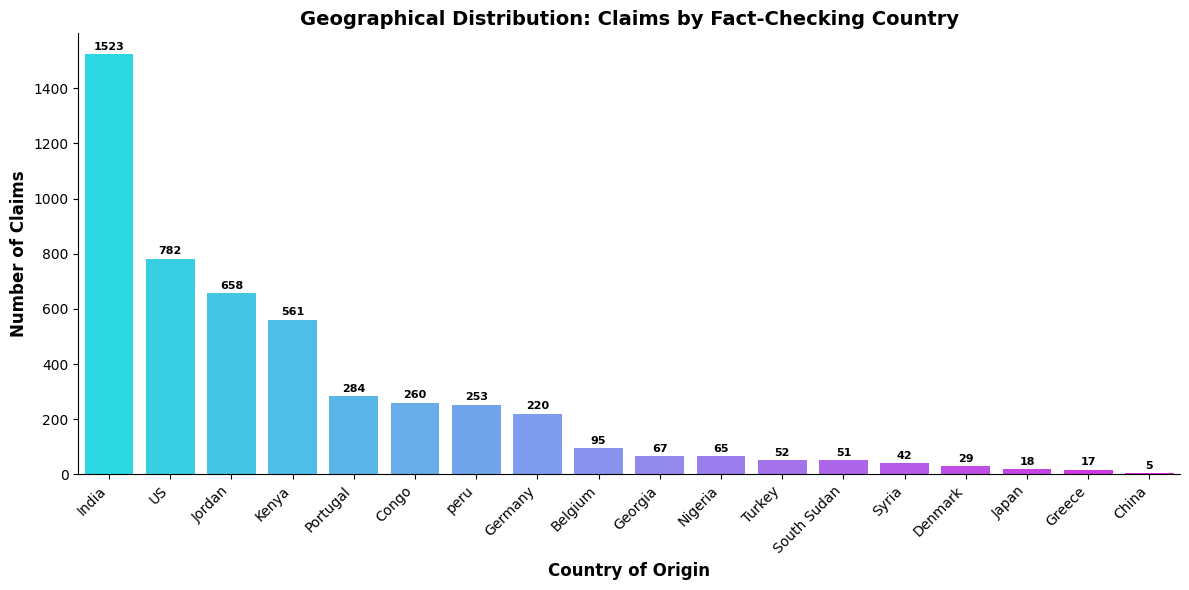

In [6]:
plt.figure(figsize=(12, 6))
country_counts = df['fc_country'].value_counts()
sns.barplot(x=country_counts.index, y=country_counts.values, palette='cool')
plt.title('Geographical Distribution: Claims by Fact-Checking Country', fontsize=14, fontweight='bold')
plt.ylabel('Number of Claims', fontsize=12, fontweight='bold')
plt.xlabel('Country of Origin', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)

# Count labels
for i, v in enumerate(country_counts.values):
    plt.text(i, v + max(country_counts.values)*0.01, str(v),
             ha='center', fontsize=8, fontweight='bold')
sns.despine() # To remove the top and right spines/borders
plt.tight_layout()
plt.savefig('../reports/eda/m4fc_geographical_distribution.png', bbox_inches='tight')
plt.show()

C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\1008199659.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_counts.index, y=language_counts.values, palette='viridis')


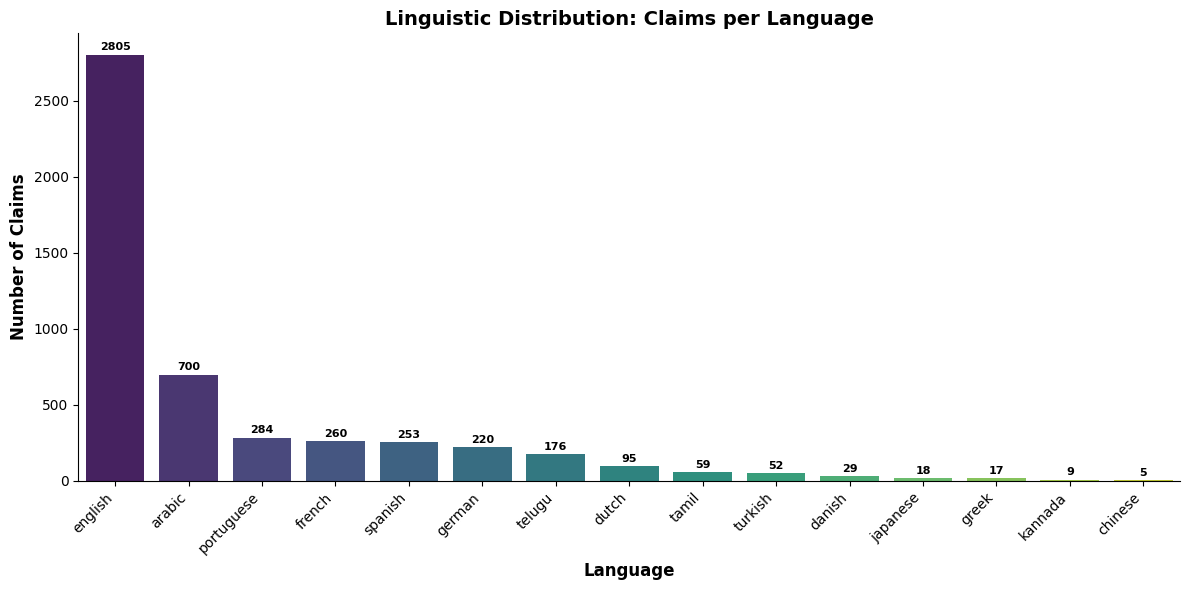

In [7]:
plt.figure(figsize=(12, 6))
language_counts = df['fc_language'].value_counts()
sns.barplot(x=language_counts.index, y=language_counts.values, palette='viridis')
plt.title('Linguistic Distribution: Claims per Language', fontsize=14, fontweight='bold')
plt.ylabel('Number of Claims', fontsize=12, fontweight='bold')
plt.xlabel('Language', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(language_counts.values):
    plt.text(i, v + max(language_counts.values)*0.01, str(v),
             ha='center', fontsize=8, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../reports/eda/m4fc_language_distribution.png', bbox_inches='tight')
plt.show()

C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\1538475443.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=org_counts.index, y=org_counts.values, palette='magma', ax=ax)


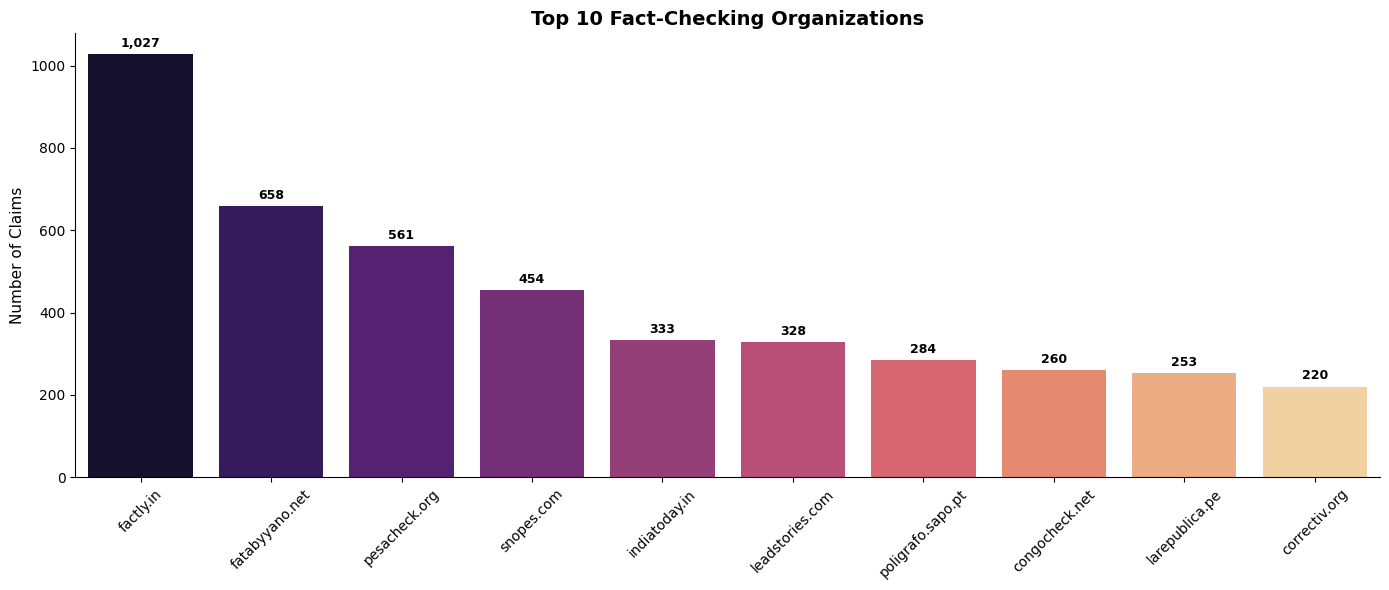

In [8]:
# Fact-Checking Organizations (Who's doing the work?)
org_counts = df['fc_org'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(14, 6))
bars = sns.barplot(x=org_counts.index, y=org_counts.values, palette='magma', ax=ax)
ax.set_title('Top 10 Fact-Checking Organizations', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Claims', fontsize=11)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

for i, v in enumerate(org_counts.values):
    ax.text(i, v + org_counts.max() * 0.01, f'{v:,}', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('../reports/eda/m4fc_top_organizations.png', bbox_inches='tight')
plt.show()

C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\1782264495.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tools_counts.index, y=tools_counts.values, palette='rocket')


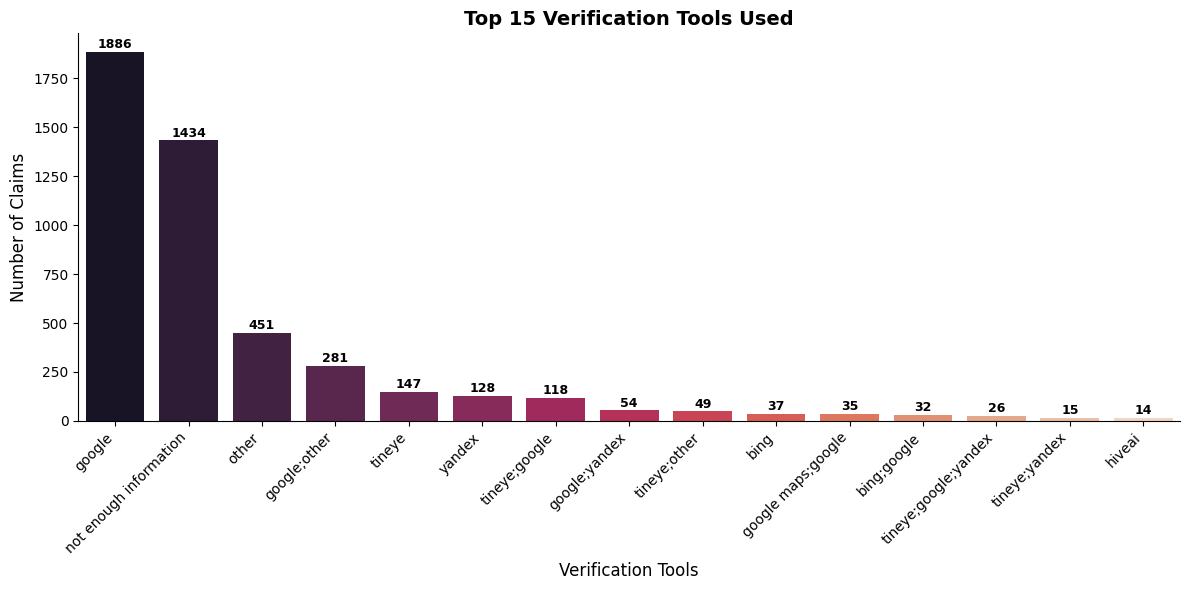

In [9]:
# Most common verification tools used by fact-checkers to verify claims
plt.figure(figsize=(12, 6))
tools_counts = df['verification_tools'].value_counts().head(15)
sns.barplot(x=tools_counts.index, y=tools_counts.values, palette='rocket')
plt.title('Top 15 Verification Tools Used', fontsize=14, fontweight='bold')
plt.ylabel('Number of Claims', fontsize=12)
plt.xlabel('Verification Tools', fontsize=12) 
plt.xticks(rotation=45, ha='right')

max_height = tools_counts.values.max()
for i, v in enumerate(tools_counts.values):
    plt.text(i, v + max_height * 0.01, str(v),
             ha='center', fontsize=9, fontweight='bold') 

sns.despine()
plt.tight_layout()
plt.savefig('../reports/eda/m4fc_verification_tools.png', bbox_inches='tight')
plt.show()

C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\3723522119.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strategy_counts.values, y=strategy_counts.index, palette='rocket', legend=False)


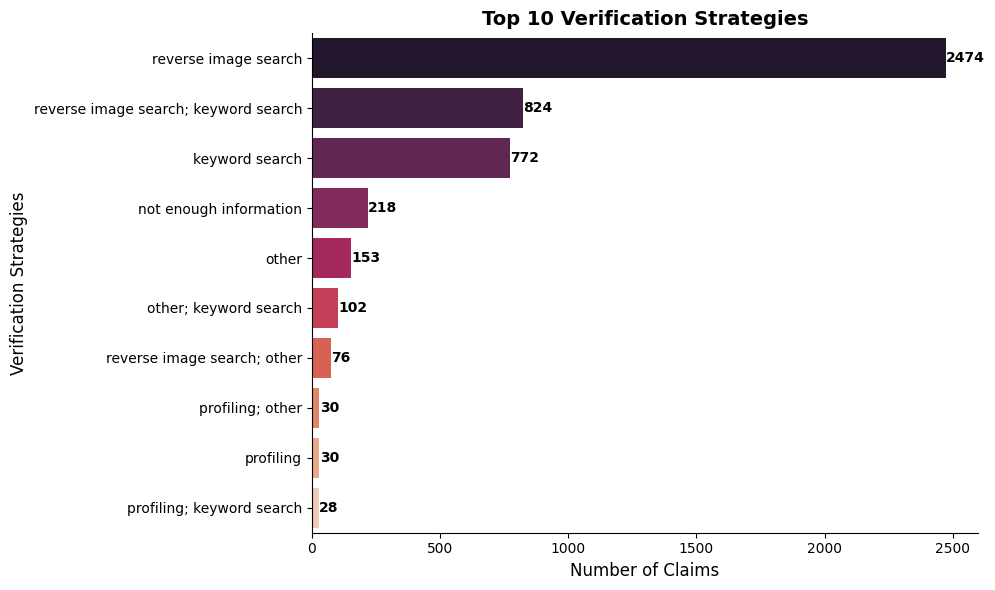

In [10]:
# Verification Strategy Usage
plt.figure(figsize=(10, 6))
strategy_counts = df['verification_strategy'].value_counts().head(10)
sns.barplot(x=strategy_counts.values, y=strategy_counts.index, palette='rocket', legend=False)
plt.title('Top 10 Verification Strategies', fontsize=14, fontweight='bold')
plt.xlabel('Number of Claims', fontsize=12)
plt.ylabel('Verification Strategies', fontsize=12) 
for i, v in enumerate(strategy_counts.values):
    plt.text(v + 1, i, str(v), va='center', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../reports/eda/m4fc_verification_strategies.png', bbox_inches='tight')
plt.show()

In [11]:
# --- Which countries have active fact-checking organizations publishing verifications --- 

# Claims per country
country_counts = df['fc_country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Claim_Count']

# Summary stats
print(f"📊 Countries with fact-checking: {country_counts['Country'].nunique()}")
print(f"📈 Total claims across all countries: {country_counts['Claim_Count'].sum():,}")
print(f"🏆 Top country: {country_counts.iloc[0]['Country']} ({country_counts.iloc[0]['Claim_Count']:,} claims)")

# Choropleth Map
fig = px.choropleth(
    country_counts,
    locations="Country",
    locationmode='country names',
    color="Claim_Count",
    hover_name="Country",
    hover_data={"Claim_Count": ":,.0f"},
    title='🌍 Global Distribution of Fact-Checked Claims',
    color_continuous_scale='Viridis', 
)

fig.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    title_x=0.5,
    title_font=dict(size=14, weight='bold'),
    coloraxis_colorbar=dict(title="Claims", tickformat=",.0f")
)
fig.write_image("../reports/eda/m4fc_global_distribution.png", width=1000, height=600)
fig.show()

📊 Countries with fact-checking: 18
📈 Total claims across all countries: 4,982
🏆 Top country: India (1,523 claims)


C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\1019611495.py:13: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [12]:
lang_div = df.groupby('fc_country')['fc_language'].nunique().sort_values(ascending=False).head(20)

print("\n" + "="*50)
print(f"🌐 LINGUISTIC DIVERSITY AUDIT")
print("="*50)
print(f"Top Multi-linguistic Hubs (Languages per Country):\n{lang_div}")
print(f"Total Unique Languages in Dataset: {df['fc_language'].nunique()}")
print("="*50)


🌐 LINGUISTIC DIVERSITY AUDIT
Top Multi-linguistic Hubs (Languages per Country):
fc_country
India          4
Belgium        1
China          1
Congo          1
Georgia        1
Denmark        1
Germany        1
Greece         1
Japan          1
Jordan         1
Kenya          1
Nigeria        1
Portugal       1
South Sudan    1
Syria          1
Turkey         1
US             1
peru           1
Name: fc_language, dtype: int64
Total Unique Languages in Dataset: 15


In [13]:
print(df['task_verdict_prediction'].value_counts()) 

task_verdict_prediction
True     4955
False      27
Name: count, dtype: int64


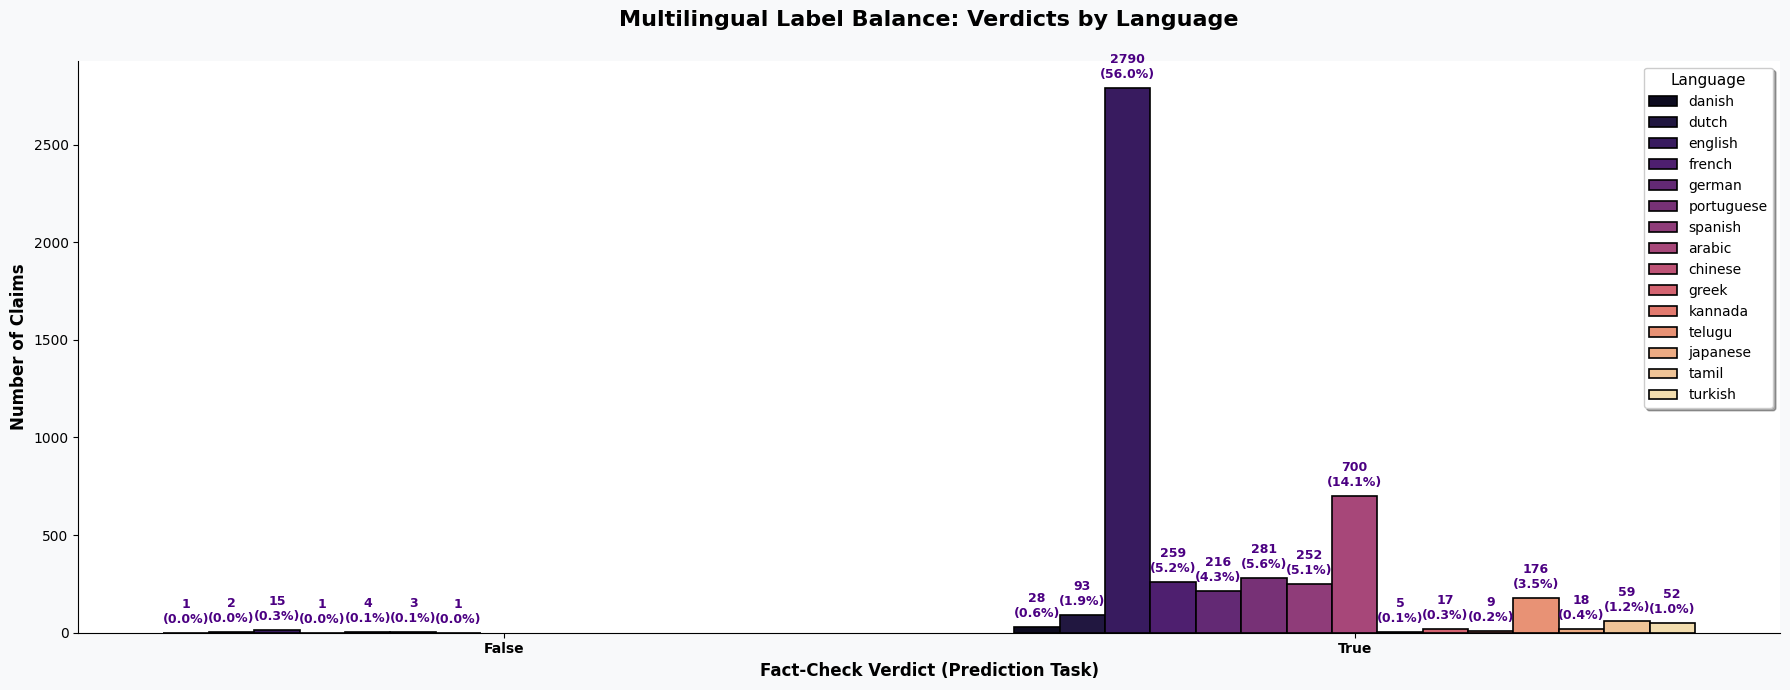

In [14]:
plt.figure(figsize=(18, 7), facecolor='#f8f9fa')
ax = sns.countplot(
    data=df, 
    x='task_verdict_prediction', 
    hue='fc_language', 
    palette='magma',
    edgecolor="black",
    linewidth=1.2
)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}\n({100*height/total:.1f}%)', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold', color="#4B0082")

plt.title('Multilingual Label Balance: Verdicts by Language', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Fact-Check Verdict (Prediction Task)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Claims', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=10, fontweight='bold')
plt.legend(title='Language', title_fontsize='11', frameon=True, shadow=True, loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig('../reports/eda/m4fc_verdict_by_language.png', bbox_inches='tight')
plt.show()

C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\3701032282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=verdict_counts.index, y=verdict_counts.values, palette="magma", legend=False)


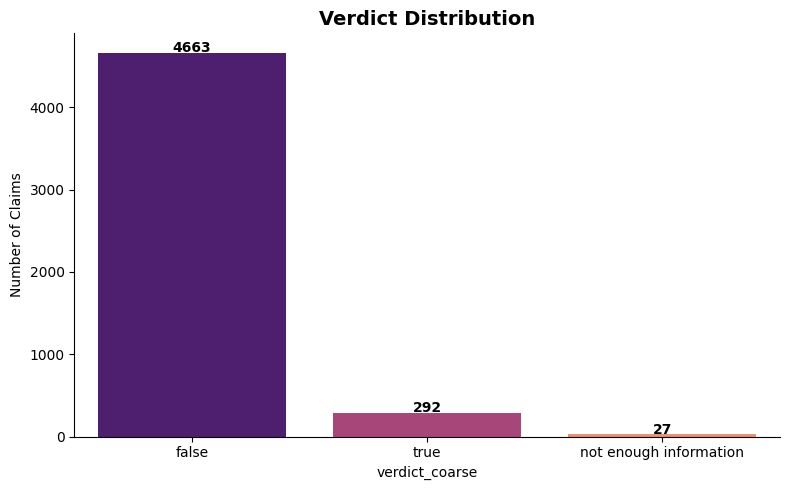

In [15]:
# Verdict Distribution 
plt.figure(figsize=(8, 5))
verdict_counts = df['verdict_coarse'].value_counts()
sns.barplot(x=verdict_counts.index, y=verdict_counts.values, palette="magma", legend=False)
plt.title('Verdict Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Claims')
for i, v in enumerate(verdict_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../reports/eda/m4fc_verdict_distribution.png', bbox_inches='tight')
plt.show()

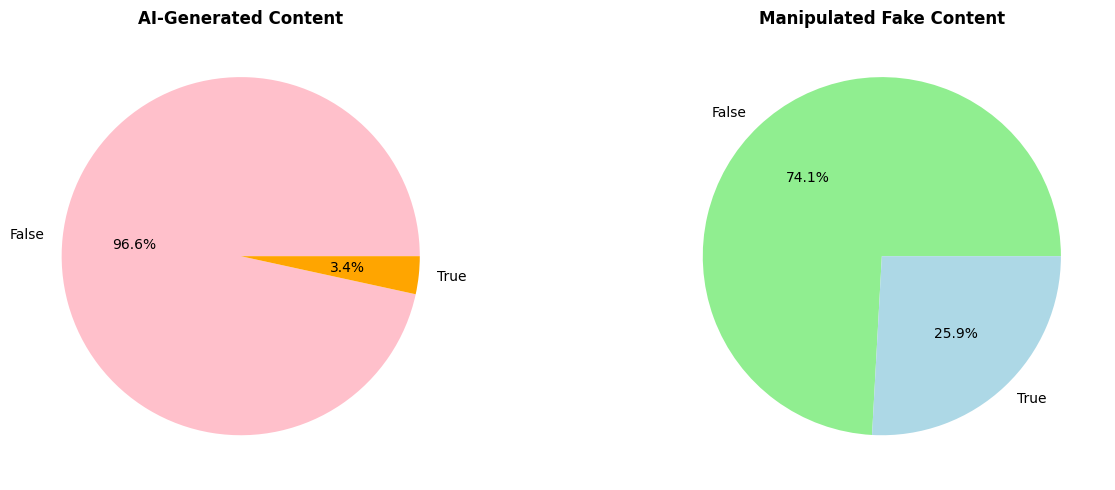

In [16]:
# AI-Generated vs Manipulated 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ai_counts = df['is_ai_generated'].value_counts()
axes[0].pie(ai_counts, labels=ai_counts.index, autopct='%1.1f%%', colors=['pink', 'orange'])
axes[0].set_title('AI-Generated Content', fontweight='bold')

manip_counts = df['is_manipulated_fake'].value_counts()
axes[1].pie(manip_counts, labels=manip_counts.index, autopct='%1.1f%%', colors=['lightgreen', 'lightblue'])
axes[1].set_title('Manipulated Fake Content', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/eda/m4fc_ai_vs_manipulated.png', bbox_inches='tight')
plt.show()

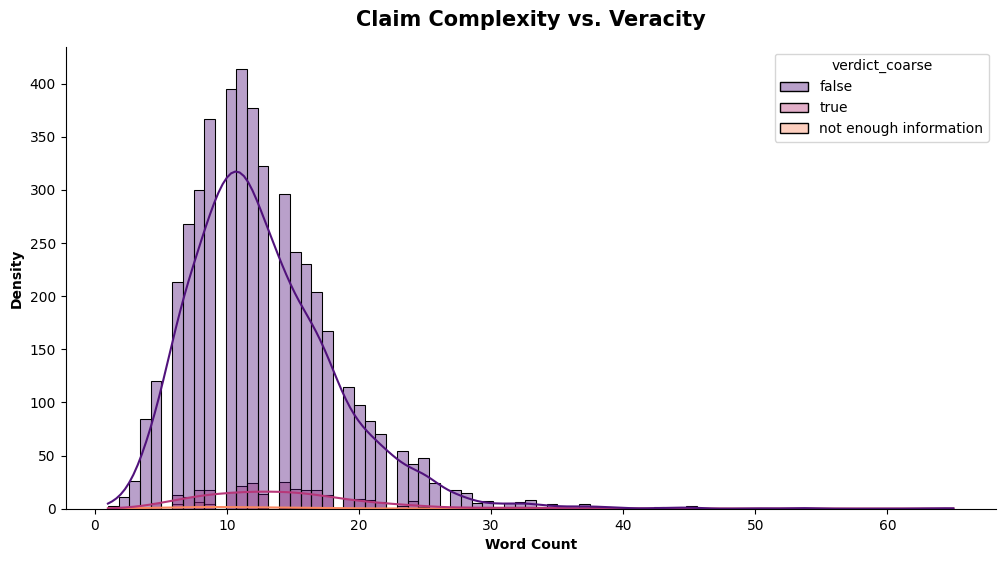

In [17]:
df['claim_word_count'] = df['claim'].str.split().str.len()

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df, 
    x='claim_word_count', 
    hue='verdict_coarse', 
    kde=True, 
    palette="magma", 
    alpha=0.4
)

plt.title('Claim Complexity vs. Veracity', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Word Count', fontweight='bold')
plt.ylabel('Density', fontweight='bold')
sns.despine()
plt.savefig('../reports/eda/m4fc_claim_length_vs_veracity.png', bbox_inches='tight', dpi=150)
plt.show()

**Data Cleaning**

📊 Final Target Distribution:
target
1.0    94.106963
0.0     5.893037
Name: proportion, dtype: float64


C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\2520865598.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette="rocket")


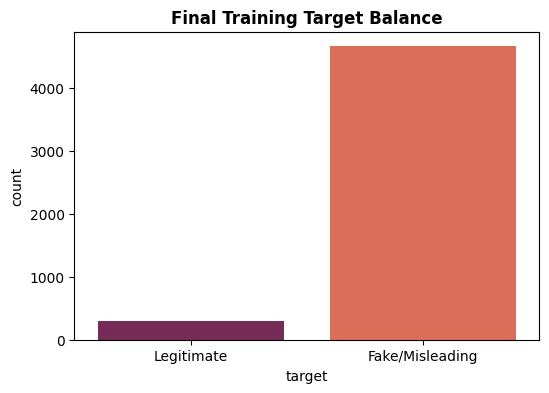

In [18]:
# Quick Check: Final Distribution
mapping = {
    'true': 0,           
    'legitimate': 0,     
    'verified': 0,       
    'fake': 1,          
    'false': 1,         
    'misleading': 1,    
    'manipulated': 1,    
    'unverified': 1,    
}

df['target'] = df['verdict_coarse'].map(mapping)
print("📊 Final Target Distribution:")
print(df['target'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette="rocket")
plt.title('Final Training Target Balance', fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fake/Misleading'])
plt.savefig('../reports/eda/m4fc_target_distribution.png', bbox_inches='tight')
plt.show()

C:\Users\SAFAE ERAJI\AppData\Local\Temp\ipykernel_57196\2679898835.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=org_stats.index, y=org_stats['Fake Rate'], palette='rocket')


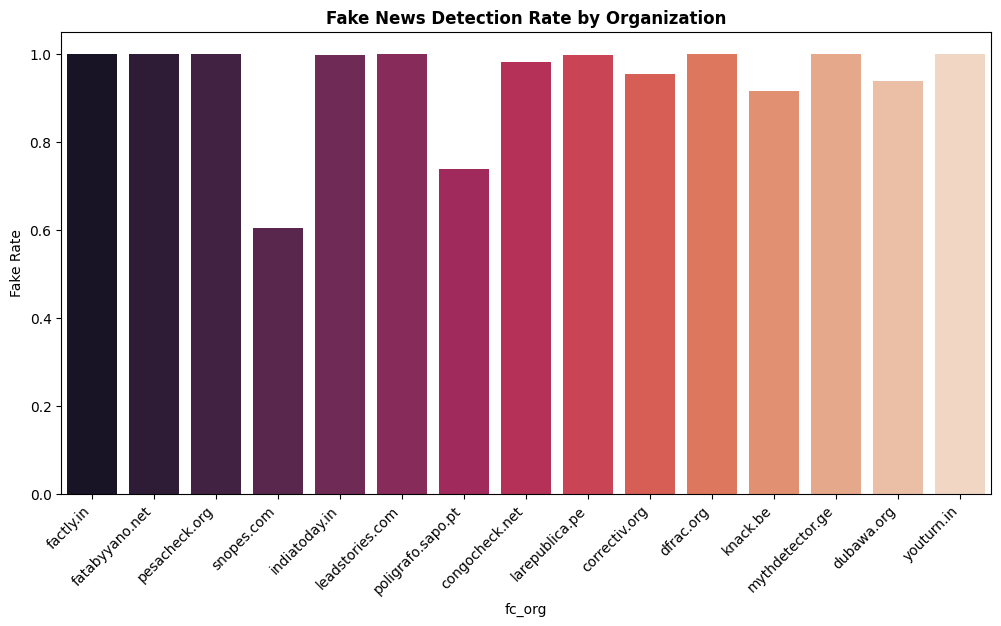

In [19]:
# 'Fake News Rate' per Organization
org_stats = df.groupby('fc_org')['target'].agg(['count', 'mean']).sort_values(by='count', ascending=False).head(15)
org_stats.columns = ['Total Claims', 'Fake Rate']

plt.figure(figsize=(12, 6))
sns.barplot(x=org_stats.index, y=org_stats['Fake Rate'], palette='rocket')
plt.title('Fake News Detection Rate by Organization', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.savefig('../reports/eda/m4fc_fake_rate_by_org.png', bbox_inches='tight')
plt.show()

In [20]:
# Remove rows where target is NaN
initial_len = len(df)
df = df.dropna(subset=['target'])
df['target'] = df['target'].astype(int)

print(f"Remaining samples: {len(df)} (dropped {initial_len - len(df)} rows with unmapped verdicts)")
print(df['target'].value_counts())
print(f"Class balance: {df['target'].value_counts(normalize=True).mul(100).round(1).to_dict()}")

Remaining samples: 4955 (dropped 27 rows with unmapped verdicts)
target
1    4663
0     292
Name: count, dtype: int64
Class balance: {1: 94.1, 0: 5.9}


In [21]:
# Remove duplicate images
print("\n" + "="*60)
print("🔍 DATA DEDUPLICATION (Prevents Train/Test Leakage)")
print("="*60)

# Check duplicate images
initial_count = len(df)
duplicate_counts = df['full_image_path'].value_counts()
duplicates = duplicate_counts[duplicate_counts > 1]
print(f"\n📊 Duplicate Analysis:")
print(f"   ├─ Total samples: {initial_count}")
print(f"   ├─ Unique images: {df['full_image_path'].nunique()}")
print(f"   ├─ Images appearing multiple times: {len(duplicates)}")
print(f"   └─ Total duplicate entries: {duplicates.sum() - len(duplicates)}")

# Keep only first occurrence of each image
df = df.drop_duplicates(subset=['full_image_path'], keep='first')
print(f"\n✅ After removing duplicate images: {len(df)} samples (removed {initial_count - len(df)})")


🔍 DATA DEDUPLICATION (Prevents Train/Test Leakage)

📊 Duplicate Analysis:
   ├─ Total samples: 4955
   ├─ Unique images: 4955
   ├─ Images appearing multiple times: 0
   └─ Total duplicate entries: 0

✅ After removing duplicate images: 4955 samples (removed 0)


In [22]:
# Remove duplicate claims
print("\n" + "="*60)
print("🔍 REMOVING DUPLICATE CLAIMS")
print("="*60)

initial_count = len(df)
claim_duplicates = df['claim'].value_counts()
claim_dups = claim_duplicates[claim_duplicates > 1]
print(f"\n📊 Claim Analysis:")
print(f"   ├─ Unique claims: {df['claim'].nunique()}")
print(f"   ├─ Claims appearing multiple times: {len(claim_dups)}")
print(f"   └─ Total duplicate claim entries: {claim_dups.sum() - len(claim_dups)}")

# Keep first occurrence of each claim
df = df.drop_duplicates(subset=['claim'], keep='first')
print(f"\n✅ After removing duplicate claims: {len(df)} samples (removed {initial_count - len(df)})")


🔍 REMOVING DUPLICATE CLAIMS

📊 Claim Analysis:
   ├─ Unique claims: 4949
   ├─ Claims appearing multiple times: 5
   └─ Total duplicate claim entries: 6

✅ After removing duplicate claims: 4949 samples (removed 6)


In [23]:
# --------------- Handle missing images (CRITICAL FOR LEAKAGE PREVENTION) ---------------
print("\n" + "="*60)
print("🔍 HANDLING MISSING IMAGES")
print("="*60)

missing_count = (~df['image_exists']).sum()
print(f"\n📊 Missing Images:")
print(f"   ├─ Samples with missing images: {missing_count}")
print(f"   └─ Percentage: {missing_count/len(df)*100:.2f}%")

# Remove samples with missing images
initial_count = len(df)
df = df[df['image_exists'] == True]
print(f"\n✅ After removing missing images: {len(df)} samples (removed {initial_count - len(df)})")


🔍 HANDLING MISSING IMAGES

📊 Missing Images:
   ├─ Samples with missing images: 1
   └─ Percentage: 0.02%

✅ After removing missing images: 4948 samples (removed 1)


**Data Splitting & Normalization**

In [24]:
pipeline = M4FCDataPipeline(
    csv_path="../../data/M4FC.csv",
    target_col="target",
    test_size=0.15,
    val_size=0.15,
    random_state = 42,
    normalize=True
)

splits = pipeline.run(verbose=True)

# Splits
X_train, y_train = splits["X_train"], splits["y_train"]
X_val, y_val = splits["X_val"], splits["y_val"]
X_test, y_test = splits["X_test"], splits["y_test"]

print(f"\n📊 Distribution (train) : {Counter(y_train)}")

📂 Dataset loaded: ../../data/M4FC.csv (4,948 rows)

📊 Distribution (train) : Counter({1: 3258, 0: 204})


**Saving**

In [25]:
os.makedirs("../data", exist_ok=True)

# Exporting cleaned unbalanced dataset to M4FC.csv
output_csv = "../../data/M4FC.csv"
df.to_csv(output_csv, index=False, encoding='utf-8')
print(f"✅ Cleaned unbalanced data exported to: {output_csv} ({len(df):,} rows)")

✅ Cleaned unbalanced data exported to: ../../data/M4FC.csv (4,948 rows)
